# Will This Customer Purchase Your Product?

<img src="rupixen-Q59HmzK38eQ-unsplash.jpg" alt="Someone is trying to purchase a produce online" width="500"/>

## 📖 Background
Online shopping decisions rely on how consumers engage with online store content. You work for a new startup company that has just launched a new online shopping website. The marketing team asks you, a new data scientist, to review a dataset of online shoppers' purchasing intentions gathered over the last year. Specifically, the team wants you to generate some insights into customer browsing behaviors in November and December, the busiest months for shoppers. You have decided to identify two groups of customers: those with a low purchase rate and returning customers. After identifying these groups, you want to determine the probability that any of these customers will make a purchase in a new marketing campaign to help gauge potential success for next year's sales.

Discover how new and returning customers shop online. Using statistics and probability techniques, you will identify the differences between their browsing habits and shopping patterns. Your insights will help the marketing team understand customer engagement on the website.



## 💾 The Data
You are given a dataset that contains several variables about each shopping session. Each shopping session corresponded to a single user. 

|Column | Description|
|--------|-----------|
|`SessionID` | unique session ID|
|`Administrative` | number of pages visited related to the customer account|
|`Administrative_Duration` | total amount of time spent (in seconds) on administrative pages|
|`Informational` | number of pages visited related to the website and the company|
|`Informational_Duration` | total amount of time spent (in seconds) on informational pages|
|`ProductRelated` | number of pages visited related to available products|
|`ProductRelated_Duration` | total amount of time spent (in seconds) on product-related pages|
|`BounceRates` | average bounce rate of pages visited by the customer|
|`ExitRates` | average exit rate of pages visited by the customer|
|`PageValues` | average page value of pages visited by the customer|
|`SpecialDay` | closeness of the site visiting time to a specific special day|
|`Weekend` | indicator whether the session is on a weekend|
|`Month` | month of the session date|
|`CustomerType` | customer type|
|`Purchase` | class label whether the customer make a purchase|

# Objectives
The marketing team asked you to analyze the behavior of online customers during November and December, the busiest months for shoppers.
1) What are the purchase rates for online shopping sessions by customer type for November and December? Store the result in a dictionary called `purchase_rates` in the format below using the exact names for keys.
> `purchase_rates = {"Returning_Customer": 0.254, "New_Customer": 0.276}`
2) What is the strongest correlation in total time spent among page types by returning customers in November and December? Store the result in a dictionary called `top_correlation` in the format below using the exact names for keys.
> `top_correlation = {"pair": (x_duration, y_duration), "correlation": 0.345}`
3) A new campaign for the returning customers will boost the purchase rate by 15%. What is the likelihood of achieving at least 100 sales out of 500 online shopping sessions for the returning customers? Store the result in a variable called `prob_at_least_100_sales`.
    - Optional: plot a binomial probability distribution chart to visualize your chances.

# Summary & Recommendations

#### Objective 1
1) What are the purchase rates for online shopping sessions by customer type for November and December?
> In November & December, there were 4,450 online shopping sessions. In these sessions, returning customers made a purchase in about 19.6% of them, whereas new customers made a purchase in about 27.3% of them. This is a difference of about 7.7%.


#### Objective 2
2) What is the strongest correlation in total time spent among page types by returning customers in November and December?
> Of the three duration-based page-type variables, the strongest relationship in this time period was between the time that returning customers spent on product-related pages & on administrative pages. Their correlation, about 0.42, constitutes a weak, positive relationship. In other words, the amount of time a returning customer spent on product-related pages tends to increase the more time they spent on administrative pages.


#### Objective 3
3) A new campaign for the returning customers will boost the purchase rate by 15%. What is the likelihood of achieving at least 100 sales out of 500 online shopping sessions for the returning customers?
> With the effects of the new campaign, the probability of returning customers making at least 100 purchases in 500 sessions is approximately 99.9998%.

### Importing

In [1]:
import pandas as pd
import numpy as np
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Import the data
orig_df = pd.read_csv("online_shopping_session_data.csv")
#inspect it
display(orig_df.head(5))
display(orig_df.info())

,SessionID,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Month,CustomerType,Purchase
0,1,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,False,Feb,Returning_Customer,0.0
1,2,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,False,Feb,Returning_Customer,0.0
2,3,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,False,Feb,Returning_Customer,0.0
3,4,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,False,Feb,Returning_Customer,0.0
4,5,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,True,Feb,Returning_Customer,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12055 entries, 0 to 12054
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   SessionID                12055 non-null  int64  
 1   Administrative           12055 non-null  int64  
 2   Administrative_Duration  12055 non-null  float64
 3   Informational            12055 non-null  int64  
 4   Informational_Duration   12055 non-null  float64
 5   ProductRelated           12055 non-null  int64  
 6   ProductRelated_Duration  12055 non-null  float64
 7   BounceRates              12055 non-null  float64
 8   ExitRates                12055 non-null  float64
 9   PageValues               12055 non-null  float64
 10  SpecialDay               12055 non-null  float64
 11  Weekend                  12055 non-null  bool   
 12  Month                    12055 non-null  object 
 13  CustomerType             12054 non-null  object 
 14  Purchase              

None

In [3]:
#Inspect the values in each column
display(orig_df.iloc[:,12].value_counts(dropna=False).sort_index())

Month
Aug      433
Dec     1589
Feb      184
Jul      432
June     287
Mar     1907
May     3364
N          1
Nov     2861
Oct      549
Sep      448
Name: count, dtype: int64

In total, there are 12,055 sessions in the dataset. There are a couple of missing values. The values in each column were also inspected to look for strange values.
- **SessionID:**
    - There is a unique value for each observation. No missing values. Span 1-12,055.
- **Administrative:**
    - No missing values. Span 0-27 pages.
- **Administrative_Duration:**
    - No missing values. Span 0-3,399 seconds, or about 0-57 minutes.
- **Informational:**
    - No missing values. Span 0-24 pages.
- **Informational_Duration:**
    - No missing values. Span 0-2,550 seconds, or about 0-43 minutes.
- **ProductRelated:**
    - No missing values. Span 0-705 pages.
- **ProductRelated_Duration:**
    - No missing values. Span 0-63,974 seconds, or about 0-18 hours.
- **BounceRates:**
    - No missing values. Span 0-0.20.
- **ExitRates:**
    - No missing values. Span 0-0.20.
- **PageValues:**
    - No missing values. Span 0-362.
- **SpecialDay:**
    - No missing values. Span 0-1.0.
- **Weekend:**
    - No missing values. 9,249 sessions were during the week, whereas 2,806 were on the weekend. This is about a 3.3:1 ratio, indicating that more sessions occurred during the week on average than on the weekend.
- **Month:**
    - No missing values. Span Feb-Dec excluding April. There is one strange value, "N," that could be a typo of "Nov." Otherwise, each month had between 184-3,364 sessions.
- **CustomerType:**
    - There is one missing value. There are 1,668 new customers & 10,386 returning customers.
- **Purchase:**
    - There is one missing value. There are 0's & 1's likely indicative of boolean values. Assuming that "0" represents a non-purchase, there were 10,195 sessions without a purchase & 1,859 sessions with a purchase.

In regard to the two missing values in the dataset, they both are present in the last session in the dataset ('SessionID' 12055). Moreover, the inconsistent 'Month' value, "N," also corresponds to this session. Given the insignificance of this single data point compared to the size of the dataset, it is reasonable to drop this data point.

In [4]:
#Clean up the dataset
#Remove the observation with the 2 missing values
clean_df = orig_df.dropna()

#Convert the 'Purchase' variable to a boolean type
clean_df['Purchase'] = clean_df.Purchase.astype('bool')

#Rename the dataset for analysis
df = clean_df.copy()

C:\Users\elija\AppData\Local\Temp\ipykernel_19852\2057293335.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['Purchase'] = clean_df.Purchase.astype('bool')


# Analysis I
1) What are the purchase rates for online shopping sessions by customer type for November and December? Store the result in a dictionary called `purchase_rates` in the format below using the exact names for keys.
> `purchase_rates = {"Returning_Customer": 0.254, "New_Customer": 0.276}`

In [14]:
#Filter for the relevant variables & sessions in Nov, Dec. There are 4,450 such sessions.
df_I = df[df.Month.isin(['Nov','Dec'])][['SessionID','Month','CustomerType','Purchase']]

#Retrieve the # purchases/non-purchases per CustomerType
NovDec_CT_Purc_splits = df_I.groupby(['CustomerType']).Purchase.value_counts().reset_index().rename(
                            columns={'count':'# sessions'})

#Want to add a variable indicating the proportion of sessions that saw a purchase per CustomerType
#Obtain the total # sessions in Nov, Dec per CustomerType
NovDec_CT_counts = df_I['CustomerType'].value_counts().reset_index().rename(columns={'count':'# total sessions'})
#Merge the totals
NovDec_CT_Purc_splits = NovDec_CT_Purc_splits.merge(NovDec_CT_counts, on='CustomerType')
#Use the numerical variables to obtain the desired purchase rates
NovDec_CT_Purc_splits['PurchaseRate'] = np.round(NovDec_CT_Purc_splits['# sessions']/NovDec_CT_Purc_splits['# total sessions'], 
                                                 3)
#Truncate the data for the desired data
NovDec_CT_PurcRates = NovDec_CT_Purc_splits[NovDec_CT_Purc_splits.Purchase == True]

#Assign the desired result (DataCamp)
NovDec_NewCust_PurcRate = NovDec_CT_PurcRates[NovDec_CT_PurcRates.CustomerType.str.contains('New')].PurchaseRate.values[0]
NovDec_RetCust_PurcRate = NovDec_CT_PurcRates[NovDec_CT_PurcRates.CustomerType.str.contains('Return')].PurchaseRate.values[0]
purchase_rates = {"Returning_Customer": NovDec_RetCust_PurcRate, "New_Customer": NovDec_NewCust_PurcRate}
display(purchase_rates)

{'Returning_Customer': 0.196, 'New_Customer': 0.273}

> In November & December, there were 4,450 online shopping sessions. In these sessions, returning customers made a purchase in about 19.6% of them, whereas new customers made a purchase in about 27.3% of them. This is a difference of about 7.7%.

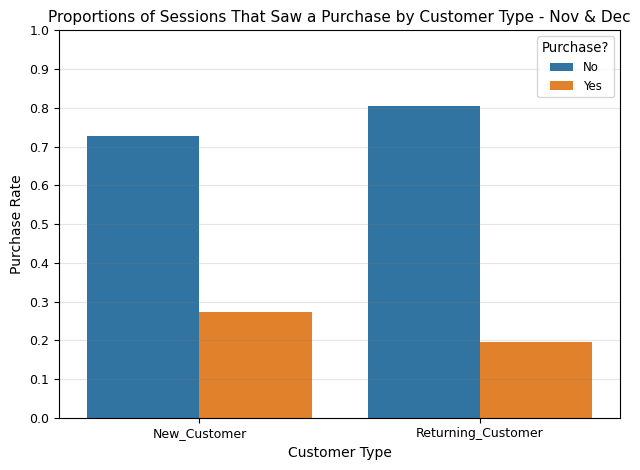

In [6]:
#Make a figure to visualize the data
ax1 = sns.barplot(data=NovDec_CT_Purc_splits, x='CustomerType', y='PurchaseRate', hue='Purchase')

#edit plot details
plt.title('Proportions of Sessions That Saw a Purchase by Customer Type - Nov & Dec', fontsize=11)
plt.xlabel('Customer Type')
plt.xticks(fontsize=9)
plt.ylabel('Purchase Rate')
plt.yticks(fontsize=9, ticks=np.arange(0,1.1,0.1))
ax1.set(ylim=(0,1))
#want to rename legend labels
leg = ax1.get_legend_handles_labels()
plt.legend(title='Purchase?', title_fontsize=9.5, fontsize=8.5, loc='upper right', handles=leg[0], labels=['No','Yes'])
plt.grid(axis='y',alpha=0.2,color='gray')
plt.tight_layout();

The figure above illustrates the rates at which different types of customers made or did not make an online purchase in November & December.  
In these months, new customers made a purchase in about 27% of their online shopping sessions, whereas returning customer made a purchase in about 19% of their sessions.

# Analysis II
2) What is the strongest correlation in total time spent among page types by returning customers in November and December? Store the result in a dictionary called `top_correlation` in the format below using the exact names for keys.
> `top_correlation = {"pair": (x_duration, y_duration), "correlation": 0.345}`

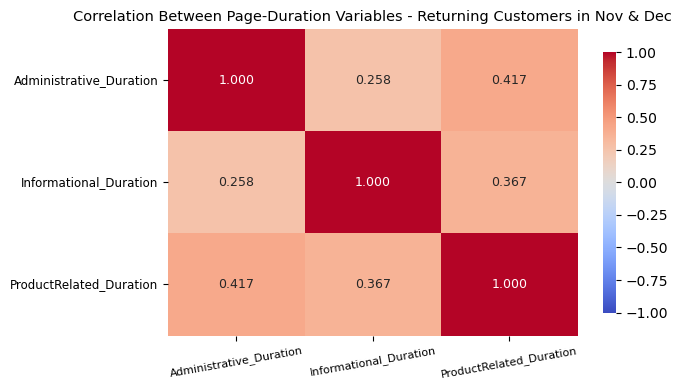

In [7]:
#Filter for the relevant data
df_II = df[(df.Month.isin(['Nov','Dec'])) & (df.CustomerType.str.contains('Return'))][['Administrative_Duration',
                                    'Informational_Duration','ProductRelated_Duration']]

#Obtain correlations between page-duration variables
NovDec_RetCust_pg_dur_corrs = df_II.corr()

#Visualize the correlations
fig = plt.figure(figsize=(7,4))
ax1 = sns.heatmap(NovDec_RetCust_pg_dur_corrs, annot=True, fmt=".3f", cmap='coolwarm', vmin=-1, vmax=1,
                  cbar_kws={'shrink':0.85}, annot_kws={'fontsize':9})
#edit plot details
plt.title('Correlation Between Page-Duration Variables - Returning Customers in Nov & Dec', fontsize=10.5)
plt.xticks(fontsize=8, rotation=10)
plt.yticks(fontsize=8.5)
plt.tight_layout();

The heatmap above portrays the correlation coefficients between the numerical variables which concern the amount of time customers spent on specific pages online. The three variables, from top to bottom, specifically correspond to the amount of time (in seconds) spent on administrative pages, information pages, & product-related pages respectively. Note that this data was condensed to returning customers that logged sessions on the website in November & December. There are 3,722 such sessions in this time frame.

Across these three variables, they appear to have weak, positive relationships with one another. According to the [National Library of Medicine](https://pmc.ncbi.nlm.nih.gov/articles/PMC3576830/), a correlation coefficient between 0.30 & 0.50 constitutes a low, positive relationship. Values smaller than 0.30 in magnitude equate to a negligible relationship. With this information, the significance of the relationships between each of these variables can be quantified.
- The relationship between the time that returning customers spent on informational pages & on administrative pages in this time period is negligible because their correlation is about 0.26. In other words, the amount of time a returning customer spent on informational pages is unrelated to that of administrative pages.
- The relationship between the time that returning customers spent on product-related pages & on administrative pages in this time period is weak & positive because their correlation is about 0.42. In other words, the amount of time a returning customer spent on product-related pages tends to increase the more time they spent on administrative pages.
- The relationship between the time that returning customers spent on informational pages & on product-related pages in this time period is weak & positive because their correlation is about 0.37. In other words, the amount of time a returning customer spent on informational pages tends to increase the more time they spent on product-related pages.

In [8]:
#Assign the variable of interest (DataCamp)
top_correlation = {"pair": ('Administrative_Duration', 'ProductRelated_Duration'), 
                   "correlation": np.round(NovDec_RetCust_pg_dur_corrs.iloc[0,2], 3)}
display(top_correlation)

{'pair': ('Administrative_Duration', 'ProductRelated_Duration'),
 'correlation': 0.417}

# Analysis III
3) A new campaign for the returning customers will boost the purchase rate by 15%. What is the likelihood of achieving at least 100 sales out of 500 online shopping sessions for the returning customers? Store the result in a variable called `prob_at_least_100_sales`.
    - Optional: plot a binomial probability distribution chart to visualize your chances.

Since it is not explicitly mentioned, the additional 15% boost in purchase rate will be added to the overall purchase rate of returning customers across the whole dataset rather than what it was specifically in November & December.

In [9]:
#Obtain the purchase rate of returning customers across all data
#Get the counts
RetCust_Purc_counts = df[df.CustomerType.str.contains('Return')]['Purchase'].value_counts().reset_index()
#Get the proportions
RetCust_Purc_props = df[df.CustomerType.str.contains('Return')]['Purchase'].value_counts(normalize=True).reset_index()
#Merge
RetCust_Purc_splits = RetCust_Purc_counts.merge(RetCust_Purc_props, on='Purchase')
display(RetCust_Purc_splits)

,Purchase,count,proportion
0,False,8945,0.861256
1,True,1441,0.138744


Across the 10,386 shopping sessions of returning customers, about 13.9% of them saw a purchase. A 15% boost would raise this rate to about 28.9%. In other words, this new campaign is theorized to result in a purchase rate of about 29% in returning customers.

To calculate the likelihood of achieving at least 100 sales out of 500 online shopping sessions for returning customers, the binomial probability distribution can be utilized. Since the 'Purchase' quantity is a binomial variable--there are two possible values--and the data points are independent, the binomial distribution is applicable. Essentially, it can be used to quantify the likelihood of achieving a specified number of "successful" outcomes in a specified number of independent trials given some probability of that "successful" result occurring. A common example involves asking how many heads you might get in a certain number of coin flips.  
In this case, the "successful" outcome is when a purchase is made.

Given the objective, a cumulative distribution function would be appropriate because it quantifies the probability of up to a certain number of successful outcomes occurring. Intrinsically, the opposite case--the probability of at least a certain number of successes--can also be calculated, which is the scenario here.

To perform these calculations, the `numpy.random` or `scipy.stats` packages can be used. Here, the latter will be used.
- To retrieve the probability of obtaining _at least_ 100 sales, the inverse calculation needs to be used. In other words, take `1 - stats.binom.cdf()`. Alternatively, the survival function, which is designed to retrieve tail probabilities (cases asking for the probability of more than a value), can be used; `stats.binom.sf()`.
- These functions take the following arguments:
    - `k` is the number of successful outcomes. In this case, k=99 because the objective is to evaluate the probability of obtaining _at least_ 100 purchases.
    - `n` is the number of independent trials in the experiment. In this case, n=500 shopping sessions.
    - `p` is the probability of a successful event (purchase) occurring. In this case, p = (the rate at which returning customers made a purchase) + (15% boost expected from the new campaign); 13.9% + 15% ~ 28.9%.

In [10]:
#Want to calculate the probability of 100 purchases occurring in 500 sessions

#Assign the corresponding probability
prob_RetCust_Purc = 0.15 + RetCust_Purc_splits.iloc[1,2]

#Perform the calculation using the survival function.
    #I checked, the inverse of the cdf is equivalent to the sf; 1 - cdf() = sf().
prob_at_least_100_sales = stats.binom.sf(k=99, n=500, p=prob_RetCust_Purc)
display(np.round(100*prob_at_least_100_sales,4))

99.9998

> With the effects of the new campaign, the probability of returning customers making at least 100 purchases in 500 sessions is approximately 99.9998%.

To expand upon this, a corresponding binomial distribution can be constructed to visualize probabilities of obtaining a certain number of outcomes.

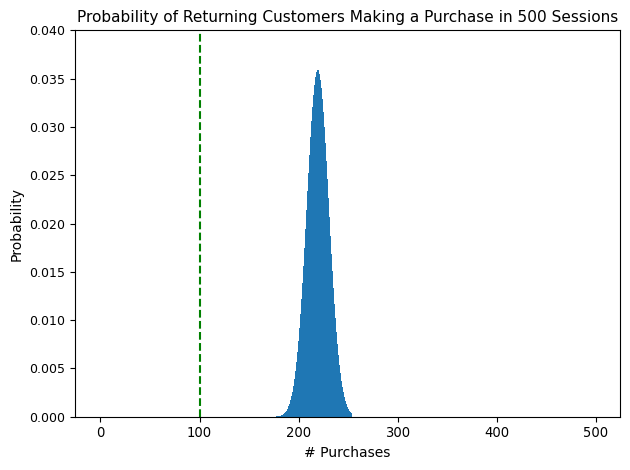

In [11]:
#Want to visualize this probability distribution

#Specify the # possible purchases (0-500)
x = np.arange(0,500)
#Obtain the probability of exactly x purchases occurring. 
    #If there are 500 trials, then there should be 501 probabilities (including 0 purchases).
temp_pmf = stats.binom.pmf(k=x, n=500, p=0.15+prob_RetCust_Purc)

#Make a probability distribution to visualize this case
plt.bar(x, temp_pmf)
#add a vertical line at 100 sales
plt.vlines(x=[100], linestyles=['--'], colors=['green'], ymin=[0], ymax=[0.04])

#edit plot details
plt.title('Probability of Returning Customers Making a Purchase in 500 Sessions', fontsize=11)
plt.xlabel('# Purchases')
plt.xticks(fontsize=9.5)
plt.ylabel('Probability')
plt.yticks(fontsize=9)
plt.ylim(0,0.04)
plt.tight_layout();

The figure above is a binomial probability distribution that concerns the likelihood of a certain number of purchases occurring based on previous online shopping sessions of returning customers. In this distribution, the probability of such a purchase occurring is about 29%. The vertical, green, dahsed line represents the goal in this section; at least 100 sales.

From this figure, it is evident that there is a significantly high likelihood that, under the assumption that the new campaign will boost the purchase rate of returning customers by 15%, there will be at least 100 purchases in 500 online shopping sessions.

## Sources
- [National Library of Medicine](https://pmc.ncbi.nlm.nih.gov/articles/PMC3576830/)